<a href="https://colab.research.google.com/github/lyntos/Python-MS/blob/main/07_Coding_Exercise_NLP_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12 Exercises — NLP



In [ ]:
!pip -q install requests beautifulsoup4 html5lib nltk textblob spacy wordcloud textatistic langdetect wikipedia-api wikipedia
# Optional for some projects:
!pip -q install googletrans==4.0.0-rc1 gTTS SpeechRecognition pyttsx3

# spaCy model download (one-time, requires internet)
!python -m spacy download en_core_web_sm

import re
import math
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

import nltk
from nltk.corpus import stopwords, gutenberg, wordnet
from nltk.tokenize import word_tokenize, sent_tokenize

from textblob import TextBlob
from textblob.sentiments import NaiveBayesAnalyzer
from textblob import Word as TBWord

import requests
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Readability
try:
  from textatistic import Textatistic
except Exception as e:
  Textatistic = None
  print("textatistic not available:", e)

# Language detect
try:
  from langdetect import detect
except Exception as e:
  detect = None
  print("langdetect not available:", e)

# spaCy
try:
  import spacy
  nlp = spacy.load("en_core_web_sm")
except Exception as e:
  nlp = None
  print("spaCy model not loaded. Run: python -m spacy download en_core_web_sm")
  print("Error:", e)

# NLTK resources
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("gutenberg", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

print("Setup complete ✅")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.3.1 which is incompatible.
google-adk 1.25.1 requires httpx<1.0.0,>=0.27.0, but you have httpx 0.13.3 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires httpx<1.0.0,>=0.27.0, but you have httpx 0.13.3 which is incompatible.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 148, in _get_module_details
  File "<frozen runpy>", line 112, in _get_module_deta

## 12.1 Web scraping (requests + BeautifulSoup) → stopwords removed → word cloud

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


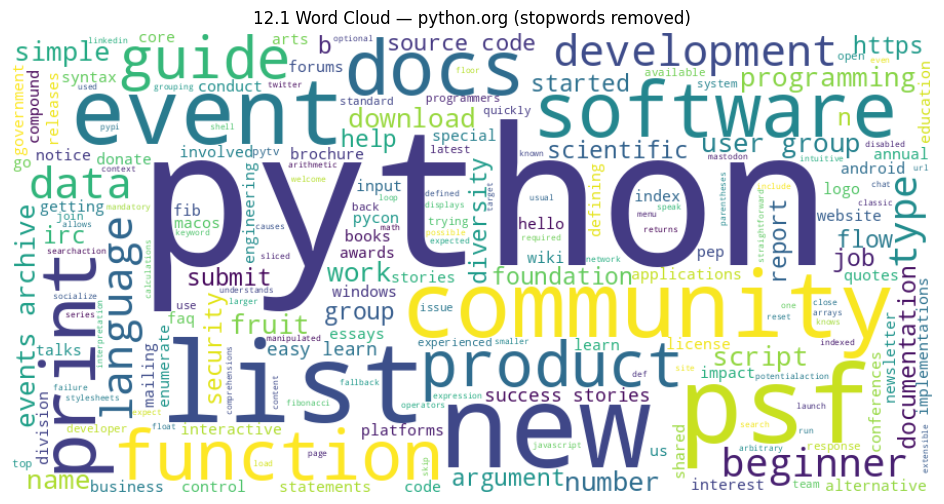

In [ ]:

nltk.download('punkt_tab')
url = "https://www.python.org"

response = requests.get(url, timeout=20)
soup = BeautifulSoup(response.content, "html5lib")
text = soup.get_text(" ", strip=True)

stop_words = set(stopwords.words("english"))
tokens = word_tokenize(text.lower())
tokens = [t for t in tokens if t.isalpha() and t not in stop_words]

wc = WordCloud(width=900, height=450, background_color="white").generate(" ".join(tokens))

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("12.1 Word Cloud — python.org (stopwords removed)")
plt.show()


## 12.2 Tokenizing text + noun phrases (TextBlob)

In [ ]:

nltk.download('brown')
blob = TextBlob(text)

print("Sentence count:", len(blob.sentences))
print("\nFirst 2 sentences:")
for s in blob.sentences[:2]:
  print("-", s)

print("\nFirst 20 words:")
print(blob.words[:20])

print("\nFirst 15 noun phrases:")
print(blob.noun_phrases[:15])


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


Sentence count: 29

First 2 sentences:
- Welcome to Python.org {
       "@context": "https://schema.org",
       "@type": "WebSite",
       "url": "https://www.python.org/",
       "potentialAction": {
         "@type": "SearchAction",
         "target": "https://www.python.org/search/?q={search_term_string}",
         "query-input": "required name=search_term_string"
       }
     } Notice: This page displays a fallback because interactive scripts did not run.
- Possible causes include disabled JavaScript or failure to load scripts or stylesheets.

First 20 words:
['Welcome', 'to', 'Python.org', 'context', 'https', 'schema.org', 'type', 'WebSite', 'url', 'https', 'www.python.org', 'potentialAction', 'type', 'SearchAction', 'target', 'https', 'www.python.org/search', 'q', 'search_term_string', 'query-input']

First 15 noun phrases:
['welcome', 'python.org', '@ context', '@ type', 'website', '@ type', 'searchaction', 'q= {', '} }', 'notice', 'page displays', 'interactive scripts', 'poss

## 12.3 Sentiment of a News Article

In [ ]:

news_url = "https://www.bbc.com/news"

try:
  r = requests.get(news_url, timeout=20, headers={"User-Agent":"Mozilla/5.0"})
  soup_news = BeautifulSoup(r.content, "html5lib")
  news_text = soup_news.get_text(" ", strip=True)
except Exception as e:
  print("Web fetch failed, using python.org text instead:", e)
  news_text = text

news_blob = TextBlob(news_text)

print("Overall sentiment (polarity, subjectivity):", news_blob.sentiment)

print("\nSentence sentiments (first 5):")
for s in news_blob.sentences[:5]:
  print("-", s.sentiment, "|", str(s)[:120], "...")


Overall sentiment (polarity, subjectivity): Sentiment(polarity=-0.35274576070404834, subjectivity=0.6847344746999416)

Sentence sentiments (first 5):
- Sentiment(polarity=0.5, subjectivity=0.7666666666666666) | BBC News - Breaking news, video and the latest top stories from the U.S. and around the world {"@context":"https://schem ...
- Sentiment(polarity=0.0, subjectivity=0.0) | BBC News provides trusted World, U.S. and U.K. news as well as local and regional perspectives. ...
- Sentiment(polarity=0.0, subjectivity=0.0) | Also entertainment, climate, business, science, technology and health news. ...
- Sentiment(polarity=-0.014502164502164584, subjectivity=0.5241702741702726) | ","url":"https://www.bbc.com/news","mainEntityOfPage":"https://www.bbc.com/news","publisher":{"@type":"NewsMediaOrganiza ...
- Sentiment(polarity=0.1, subjectivity=0.1) | UK will allow US to use bases to strike Iranian missile sites, PM says The prime minister says it remains the case that  ...


## 12.4 Sentiment (NaiveBayesAnalyzer)

In [ ]:

nltk.download('movie_reviews')

nb_blob = TextBlob(news_text, analyzer=NaiveBayesAnalyzer())

print("Overall NaiveBayes sentiment:", nb_blob.sentiment)

print("\nSentence sentiments (first 5):")
for s in nb_blob.sentences[:5]:
  s_nb = TextBlob(str(s), analyzer=NaiveBayesAnalyzer())
  print("-", s_nb.sentiment, "|", str(s)[:120], "...")


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


Overall NaiveBayes sentiment: Sentiment(classification='pos', p_pos=1.0, p_neg=3.478512514343034e-80)

Sentence sentiments (first 5):
- Sentiment(classification='pos', p_pos=0.9501328856734428, p_neg=0.0498671143265546) | BBC News - Breaking news, video and the latest top stories from the U.S. and around the world {"@context":"https://schem ...
- Sentiment(classification='pos', p_pos=0.9337600059891353, p_neg=0.06623999401086444) | BBC News provides trusted World, U.S. and U.K. news as well as local and regional perspectives. ...
- Sentiment(classification='pos', p_pos=0.8241655374406719, p_neg=0.17583446255932658) | Also entertainment, climate, business, science, technology and health news. ...
- Sentiment(classification='pos', p_pos=1.0, p_neg=2.9773681652783187e-19) | ","url":"https://www.bbc.com/news","mainEntityOfPage":"https://www.bbc.com/news","publisher":{"@type":"NewsMediaOrganiza ...
- Sentiment(classification='pos', p_pos=0.9735784679847493, p_neg=0.02642153201525368) | UK w

## 12.5 Spell check a Project Gutenberg Book

In [ ]:

book_id = "austen-emma.txt"
book_text = gutenberg.raw(book_id)[:20000]

book_blob = TextBlob(book_text)
words = [w.lower() for w in book_blob.words if w.isalpha()]

unique_words = list(dict.fromkeys(words))[:250]

misspelled = []
for w in unique_words:
  suggestions = TBWord(w).spellcheck()
  if suggestions and suggestions[0][0] != w:
    misspelled.append((w, suggestions[:3]))

misspelled[:15]


[('austen', [('austin', 1.0)]),
 ('woodhouse', [('workhouse', 0.5), ('poorhouse', 0.5)]),
 ('caresses', [('caressed', 1.0)]),
 ('alloy',
  [('allow', 0.8053097345132744),
   ('ally', 0.08849557522123894),
   ('allay', 0.05309734513274336)]),
 ('enjoyments', [('enjoyment', 1.0)]),
 ('unperceived', [('perceived', 1.0)]),
 ('weston',
  [('west', 0.39502762430939226),
   ('western', 0.16160220994475138),
   ('lesion', 0.1408839779005525)])]

## 12.6 Hamlet: Top-20 bar chart + masked word cloud

In [ ]:

hamlet = gutenberg.raw("shakespeare-hamlet.txt")
stop_words = set(stopwords.words("english"))

tokens = word_tokenize(hamlet.lower())
tokens = [t for t in tokens if t.isalpha() and t not in stop_words]

counts = Counter(tokens)
df_top20 = pd.DataFrame(counts.most_common(20), columns=["word","count"])
df_top20


,word,count
0,ham,337
1,lord,211
2,haue,175
3,king,172
4,shall,107
5,come,104
6,let,104
7,thou,104
8,hamlet,100
9,good,98


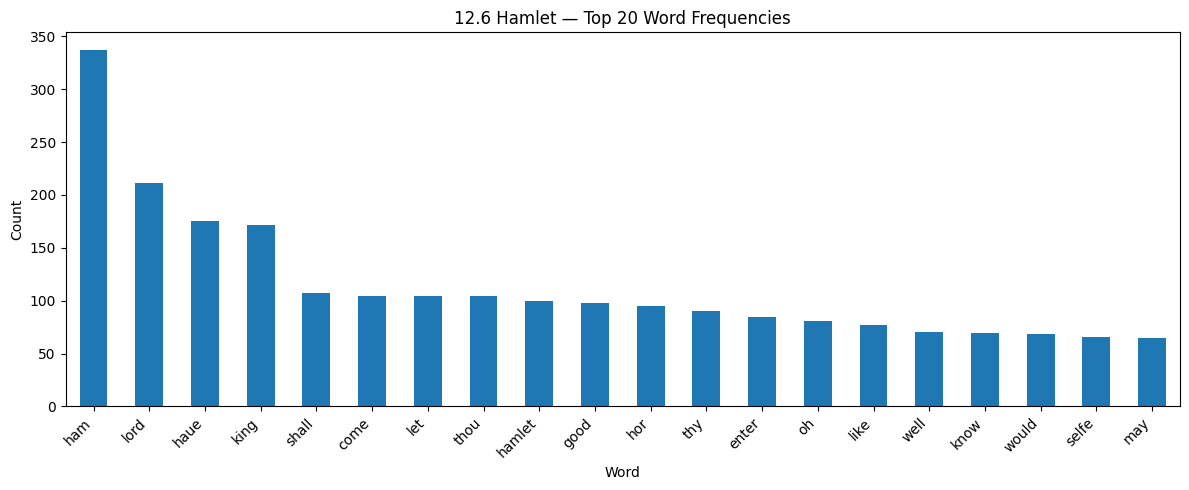

In [ ]:

ax = df_top20.plot(kind="bar", x="word", y="count", legend=False, figsize=(12, 5))
ax.set_title("12.6 Hamlet — Top 20 Word Frequencies")
ax.set_xlabel("Word")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


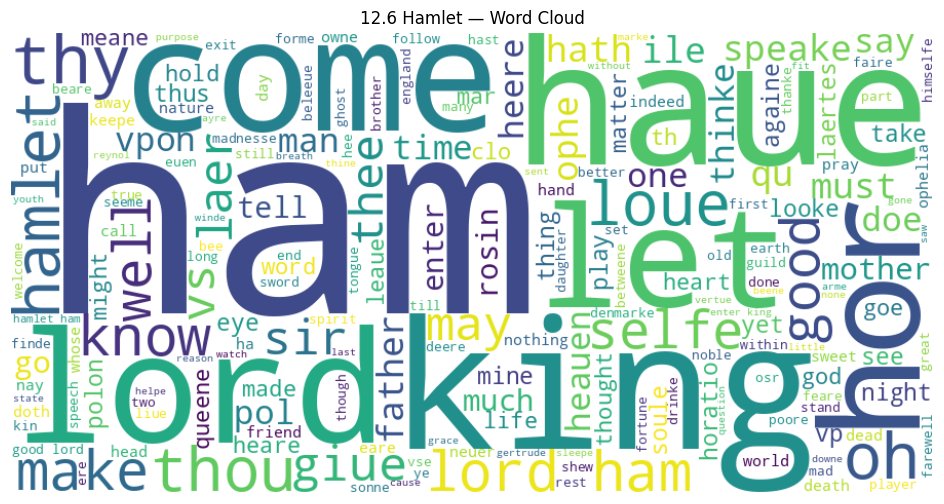

In [ ]:

mask_path = Path("mask_oval.png")
mask = None

if mask_path.exists():
  from PIL import Image
  mask = np.array(Image.open(mask_path))

wc = WordCloud(width=900, height=450, background_color="white", mask=mask).generate(" ".join(tokens))

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("12.6 Hamlet — Word Cloud" + (" (masked)" if mask is not None else ""))
plt.show()


## 12.7 Readability of News Articles (Textatistic + simple stats)

In [ ]:

def basic_readability_stats(corpus):
  sentences = sent_tokenize(corpus)
  words = [w for w in word_tokenize(corpus) if w.isalpha()]

  if not sentences or not words:
    return {"words_per_sentence": 0, "chars_per_word": 0, "syllables_per_word": 0}

  words_per_sentence = len(words) / len(sentences)
  chars_per_word = sum(len(w) for w in words) / len(words)

  def syllables(word):
    groups = re.findall(r"[aeiouy]+", word.lower())
    return max(1, len(groups))

  syllables_per_word = sum(syllables(w) for w in words) / len(words)

  return {"words_per_sentence": words_per_sentence, "chars_per_word": chars_per_word, "syllables_per_word": syllables_per_word}

urls = ["https://www.python.org", "https://www.wikipedia.org"]  # replace with news article URLs (same topic)

rows = []
for u in urls:
  try:
    r = requests.get(u, timeout=20, headers={"User-Agent":"Mozilla/5.0"})
    soup = BeautifulSoup(r.content, "html5lib")
    t = soup.get_text(" ", strip=True)
  except Exception:
    t = "Fallback text."
  stats = basic_readability_stats(t)
  stats["url"] = u
  if Textatistic is not None:
    try:
      stats["flesch"] = Textatistic(t).flesch_score
    except Exception:
      stats["flesch"] = None
  else:
    stats["flesch"] = None
  rows.append(stats)

pd.DataFrame(rows)[["url","words_per_sentence","chars_per_word","syllables_per_word","flesch"]]


,url,words_per_sentence,chars_per_word,syllables_per_word,flesch
0,https://www.python.org,29.793103,5.515046,1.922454,62.940035
1,https://www.wikipedia.org,189.333333,5.465141,1.925704,NaN


## 12.8 spaCy: Named Entity Recognition

In [ ]:

article_url = "https://www.python.org"

try:
  r = requests.get(article_url, timeout=20, headers={"User-Agent":"Mozilla/5.0"})
  soup = BeautifulSoup(r.content, "html5lib")
  article_text = soup.get_text(" ", strip=True)
except Exception:
  article_text = "Barack Obama visited New York in 2016 and met Apple executives in California."

if nlp is None:
  print("spaCy model not available.")
else:
  doc = nlp(article_text[:3000])
  ents = [(ent.text, ent.label_) for ent in doc.ents]
  pd.DataFrame(ents, columns=["entity","label"]).head(30)


## 12.9 spaCy: Similarity Detection (multiple articles)

In [ ]:

article_urls = ["https://www.python.org", "https://www.python.org/about/"]

texts = []
for u in article_urls:
  try:
    r = requests.get(u, timeout=20, headers={"User-Agent":"Mozilla/5.0"})
    soup = BeautifulSoup(r.content, "html5lib")
    t = soup.get_text(" ", strip=True)
  except Exception:
    t = ""
  texts.append(t[:4000])

if nlp is None:
  print("spaCy model not available.")
else:
  docs = [nlp(t) for t in texts]
  for i in range(len(docs)):
    for j in range(i+1, len(docs)):
      print(f"Similarity({i}, {j}) =", docs[i].similarity(docs[j]))


Similarity(0, 1) = 0.7789583206176758


/tmp/ipython-input-310/910084454.py:19: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  print(f"Similarity({i}, {j}) =", docs[i].similarity(docs[j]))


## 12.10 Shakespeare similarity detection

In [ ]:

print("Available Shakespeare files:", [f for f in gutenberg.fileids() if f.startswith("shakespeare")])

sh1 = gutenberg.raw("shakespeare-hamlet.txt")[:20000]
sh2 = gutenberg.raw("shakespeare-macbeth.txt")[:20000]

if nlp is None:
  print("spaCy model not available.")
else:
  print("Similarity(Hamlet, Macbeth) =", nlp(sh1).similarity(nlp(sh2)))


Available Shakespeare files: ['shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt']
Similarity(Hamlet, Macbeth) = 0.9836427569389343


/tmp/ipython-input-310/1393822034.py:9: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  print("Similarity(Hamlet, Macbeth) =", nlp(sh1).similarity(nlp(sh2)))


## 12.11 textblob.utils utility functions



In [ ]:

from textblob.utils import strip_punc, lowerstrip

romeo_sample = "O Romeo, Romeo! wherefore art thou Romeo? Deny thy father and refuse thy name."

print("Original:", romeo_sample)
print("strip_punc(all=True):", strip_punc(romeo_sample, all=True))
print("lowerstrip(all=True):", lowerstrip(romeo_sample, all=True))


Original: O Romeo, Romeo! wherefore art thou Romeo? Deny thy father and refuse thy name.
strip_punc(all=True): O Romeo Romeo wherefore art thou Romeo Deny thy father and refuse thy name
lowerstrip(all=True): o romeo romeo wherefore art thou romeo deny thy father and refuse thy name


## 12.15 Readability Scores with Textatistic (famous authors)

In [ ]:

books = ["austen-emma.txt", "melville-moby_dick.txt", "bible-kjv.txt", "shakespeare-hamlet.txt"]

rows = []
for b in books:
  t = gutenberg.raw(b)[:40000]
  score = Textatistic(t).flesch_score if Textatistic is not None else None
  rows.append({"book": b, "flesch_reading_ease": score})

pd.DataFrame(rows).sort_values(by="flesch_reading_ease", ascending=False)


,book,flesch_reading_ease
3,shakespeare-hamlet.txt,93.555307
1,melville-moby_dick.txt,85.390831
2,bible-kjv.txt,81.846220
0,austen-emma.txt,78.650334


## 12.16 Shakespeare authorship question (similarity to Macbeth)

In [ ]:

targets = {
  "Macbeth (Shakespeare)": gutenberg.raw("shakespeare-macbeth.txt")[:25000],
  "Moby Dick (Melville)": gutenberg.raw("melville-moby_dick.txt")[:25000],
  "Emma (Austen)": gutenberg.raw("austen-emma.txt")[:25000],
  "KJV Bible": gutenberg.raw("bible-kjv.txt")[:25000],
}

if nlp is None:
  print("spaCy model not available.")
else:
  docs = {k: nlp(v) for k, v in targets.items()}
  base = docs["Macbeth (Shakespeare)"]
  results = [(k, base.similarity(d)) for k, d in docs.items() if k != "Macbeth (Shakespeare)"]
  pd.DataFrame(results, columns=["text","similarity_to_macbeth"]).sort_values(by="similarity_to_macbeth", ascending=False)


/tmp/ipython-input-310/3887422361.py:13: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  results = [(k, base.similarity(d)) for k, d in docs.items() if k != "Macbeth (Shakespeare)"]


## 12.17 Similarity via POS-frequency dictionaries

In [ ]:

nltk.download('averaged_perceptron_tagger_eng')
nltk.download("averaged_perceptron_tagger", quiet=True)

def pos_freq_dict(text):
  tokens = [w for w in word_tokenize(text) if w.isalpha()]
  tags = [t for _, t in nltk.pos_tag(tokens)]
  return Counter(tags)

def cosine_sim(counter_a, counter_b):
  keys = set(counter_a) | set(counter_b)
  va = np.array([counter_a.get(k, 0) for k in keys], dtype=float)
  vb = np.array([counter_b.get(k, 0) for k in keys], dtype=float)
  denom = np.linalg.norm(va) * np.linalg.norm(vb)
  return float(va.dot(vb) / denom) if denom else 0.0

t1 = gutenberg.raw("austen-emma.txt")[:20000]
t2 = gutenberg.raw("austen-persuasion.txt")[:20000]
t3 = gutenberg.raw("melville-moby_dick.txt")[:20000]

d1, d2, d3 = pos_freq_dict(t1), pos_freq_dict(t2), pos_freq_dict(t3)

print("Austen vs Austen:", cosine_sim(d1, d2))
print("Austen vs Melville:", cosine_sim(d1, d3))


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Austen vs Austen: 0.9782547735816708
Austen vs Melville: 0.8661879792413535


## 12.21 Translate “Peace” + circular word cloud

In [ ]:

# One thing I have to tweak further is using google translate for the translations.
# I noticed translate from TextBlob is deprecated. I am doing a rush a work!
# Not helpful, Martin... no last minute crunch work.

word = "Peace"
lang_codes = ["es","fr","de","it","pt","ar","sw","hi","zh-cn","ja","ko"]

try:
  from googletrans import LANGUAGES
  lang_codes = list(LANGUAGES.keys())[:30]
except Exception:
  pass

translations = []
for code_ in lang_codes:
  try:
    print(TextBlob(word))
    print(TextBlob(word).translate(to=code_))
    translations.append(str(TextBlob(word).translate(to=code_)))
  except Exception:
    continue

print("Translations:", len(translations))
print(translations[:10])


Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Peace
Translations: 0
[]


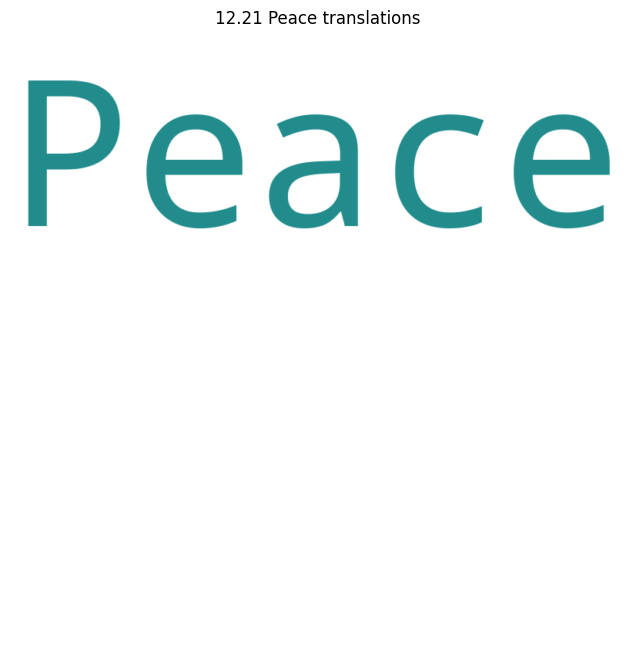

In [ ]:

mask_path = Path("mask_circle.png")
mask = None

if mask_path.exists():
  from PIL import Image
  mask = np.array(Image.open(mask_path))

wc = WordCloud(width=800, height=800, background_color="white", collocations=False, mask=mask)\
  .generate(" ".join(translations) if translations else "Peace")

plt.figure(figsize=(8, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("12.21 Peace translations")
plt.show()


## 12.22 Self tutor template (speech → translate → speak)


In [ ]:

# Yet to get this to work on my laptop

import speech_recognition as sr
from gtts import gTTS
import os
from textblob import TextBlob

target_lang = "es"  # Spanish

r = sr.Recognizer()
with sr.Microphone() as source:
  print("Say something in English...")
  audio = r.listen(source)

english_text = r.recognize_google(audio)
print("You said:", english_text)

translated = str(TextBlob(english_text).translate(to=target_lang))
print("Translated:", translated)

tts = gTTS(translated, lang=target_lang)
tts.save("out.mp3")
os.system("open out.mp3")  # macOS; use 'start' on Windows


AttributeError: Could not find PyAudio; check installation

## 12.23 Wikipedia access example

In [ ]:

try:
  import wikipediaapi
  wiki = wikipediaapi.Wikipedia("en")
  page = wiki.page("Python (programming language)")

  print("Title:", page.title)
  print("Summary:", page.summary[:500], "...")
  print("\nSections:")
  for s in page.sections[:6]:
    print("-", s.title)
except Exception as e:
  print("wikipedia-api not available:", e)


wikipedia-api not available: Please, be nice to Wikipedia and specify user agent - https://meta.wikimedia.org/wiki/User-Agent_policy. Current user_agent: 'en' is not sufficient. Use Wikipedia(user_agent='your-user-agent', language='en')


## 12.24 Summarization

In [ ]:

sample_text = gutenberg.raw("austen-emma.txt")[:40000]

def simple_freq_summary(text, n_sentences=5):
  sentences = sent_tokenize(text)
  sw = set(stopwords.words("english"))
  words = [w.lower() for w in word_tokenize(text) if w.isalpha() and w.lower() not in sw]
  freq = Counter(words)

  def score(sentence):
    ws = [w.lower() for w in word_tokenize(sentence) if w.isalpha()]
    return sum(freq.get(w, 0) for w in ws)

  ranked = sorted(sentences, key=score, reverse=True)
  return " ".join(ranked[:n_sentences])

try:
  from gensim.summarization import summarize, keywords
  print("Gensim summary:\n", summarize(sample_text))
  print("\nKeywords:\n", keywords(sample_text))
except Exception as e:
  print("Gensim summarization not available:", e)
  print("\nFallback summary:\n", simple_freq_summary(sample_text))


Gensim summarization not available: No module named 'gensim'

Fallback summary:
 Matrimony, as the origin of change,
was always disagreeable; and he was by no means yet reconciled
to his own daughter's marrying, nor could ever speak of her but
with compassion, though it had been entirely a match of affection,
when he was now obliged to part with Miss Taylor too; and from
his habits of gentle selfishness, and of being never able to
suppose that other people could feel differently from himself,
he was very much disposed to think Miss Taylor had done as sad
a thing for herself as for them, and would have been a great deal
happier if she had spent all the rest of her life at Hartfield. Mr. Knightley, in fact, was one of the few people who could see
faults in Emma Woodhouse, and the only one who ever told her of them:
and though this was not particularly agreeable to Emma herself,
she knew it would be so much less so to her father, that she would
not have him really suspect such a circumsta

## 12.26 Synonym chain to antonym (WordNet)

In [ ]:

def wordnet_synonyms(word):
  syns = set()
  for syn in wordnet.synsets(word):
    for lemma in syn.lemmas():
      syns.add(lemma.name().replace("_"," "))
  return syns

def wordnet_antonyms(word):
  ants = set()
  for syn in wordnet.synsets(word):
    for lemma in syn.lemmas():
      for ant in lemma.antonyms():
        ants.add(ant.name().replace("_"," "))
  return ants

def find_chain_to_antonym(start_word, max_depth=5):
  start_word = start_word.lower()
  antonyms = wordnet_antonyms(start_word)
  if not antonyms:
    return None, antonyms

  queue = [(start_word, [start_word], 0)]
  visited = set([start_word])

  while queue:
    current, path, depth = queue.pop(0)
    if depth >= max_depth:
      continue
    for syn in wordnet_synonyms(current):
      s = syn.lower()
      if s in antonyms:
        return path + [s], antonyms
      if s not in visited:
        visited.add(s)
        queue.append((s, path + [s], depth + 1))

  return None, antonyms

chain, ants = find_chain_to_antonym("happy", max_depth=5)
print("Antonyms:", list(ants)[:10])
print("Chain:", " -> ".join(chain) if chain else "No chain found")


Antonyms: ['unhappy']
Chain: No chain found


## 12.27 Text steganography (whitespace encoding)

In [ ]:
# Not working yet. Need to debug some more.

def to_bits(message):
  return "".join(f"{ord(c):08b}" for c in message)

def from_bits(bits):
  chars = []
  for i in range(0, len(bits), 8):
    byte = bits[i:i+8]
    if len(byte) < 8:
      break
    chars.append(chr(int(byte, 2)))
  return "".join(chars)

def hide_message(carrier, secret):
  bits = to_bits(secret) + "00000000"  # null terminator
  words = carrier.split()
  if len(bits) > len(words):
    raise ValueError("Carrier text too short for this secret.")

  out = []
  for i, w in enumerate(words):
    out.append(w)
    out.append("  " if i < len(bits) and bits[i] == "1" else " ")
  return "".join(out).rstrip()

def reveal_message(stego):
  bits = []
  i = 0
  while i < len(stego) - 1:
    while i < len(stego) and stego[i] == " ":
      i += 1
    while i < len(stego) and stego[i] != " ":
      i += 1
    space_count = 0
    while i < len(stego) and stego[i] == " ":
      space_count += 1
      i += 1
    if space_count >= 2:
      bits.append("1")
    elif space_count == 1:
      bits.append("0")

    if len(bits) % 8 == 0 and len(bits) >= 8:
      last_char = from_bits("".join(bits[-8:]))
      if last_char == "\x00":
        return from_bits("".join(bits[:-8]))
  return from_bits("".join(bits))

carrier = "This is a simple carrier text used to hide a secret message using spaces between words for a quick demo."
secret = "HELLO"

stego = hide_message(carrier, secret)
print("Recovered:", reveal_message(stego))


ValueError: Carrier text too short for this secret.